<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo?
La columna income.
2. ¿Qué representa dicha variable?
Representa si una persona gana 50 mil dolares anuales o menos, o si gana mas de esa cantidad.
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
El nivel educativo, la edad, la ocupacion y las ganancias de capital.
4. ¿Cuántas variables predictoras existen?
Existen catorce variables predictoras en total.
5. ¿Por qué fue necesario transformar variables categóricas?
Porque los modelos matematicos requieren valores numericos puros para poder procesar la informacion.
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
Se generaron alrededor de ochenta y cinco columnas nuevas.
8. ¿Existen valores nulos?
Si, vienen representados inicialmente con un signo de interrogacion.
9. ¿Qué variables son numéricas?
Edad, peso final, nivel educativo numerico, ganancia de capital, perdida de capital y horas por semana.
10. ¿Qué variables son categóricas?
Clase laboral, educacion, estado civil, ocupacion, relacion familiar, raza, sexo y pais de origen.
11. ¿Cuántos registros quedaron en entrenamiento?
Quedaron aproximadamente 24129 registros.
12. ¿Cuántos registros quedaron en prueba?
Quedaron aproximadamente 6033 registros.
13. ¿Por qué no debemos entrenar utilizando todos los datos?
Para evitar el sobreajuste y tener datos sin usar con los cuales evaluar el rendimiento real del modelo.
14. ¿Cuál fue el Accuracy obtenido?
Un 81 por ciento de precision aproximadamente.
15. ¿Consideras que el resultado es adecuado?
Si, es un buen punto de partida base para este conjunto de datos.
16. ¿Qué factores podrían afectar el desempeño del modelo?
El desbalance de las clases a predecir y la profundidad limite que se le de al arbol de decision.
18. ¿Cuál fue la variable más importante?
La ganancia de capital financiera.
19. ¿Cuál fue la menos importante?
Las variables de paises de origen que tenian muy pocos registros de personas.
20. ¿Coinciden los resultados con tus hipótesis iniciales?
Si, ya que el modelo confirmo que la preparacion academica y las finanzas dictan los ingresos.
21. ¿Qué variables aportan más información al modelo?
Las variables financieras y las de perfil sociodemografico como la edad y la educacion.

# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import kagglehub

In [4]:
#Carga del dataset
path = kagglehub.dataset_download("uciml/adult-census-income")

100%|██████████| 450k/450k [00:00<00:00, 69.6MB/s]

Extracting files...


In [5]:
df = pd.read_csv(f"{path}/adult.csv")

In [6]:
df.replace('?', np.nan, inplace=True)

In [7]:
print("=== VISTAZO A LOS DATOS ===")
display(df.head())

=== VISTAZO A LOS DATOS ===


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


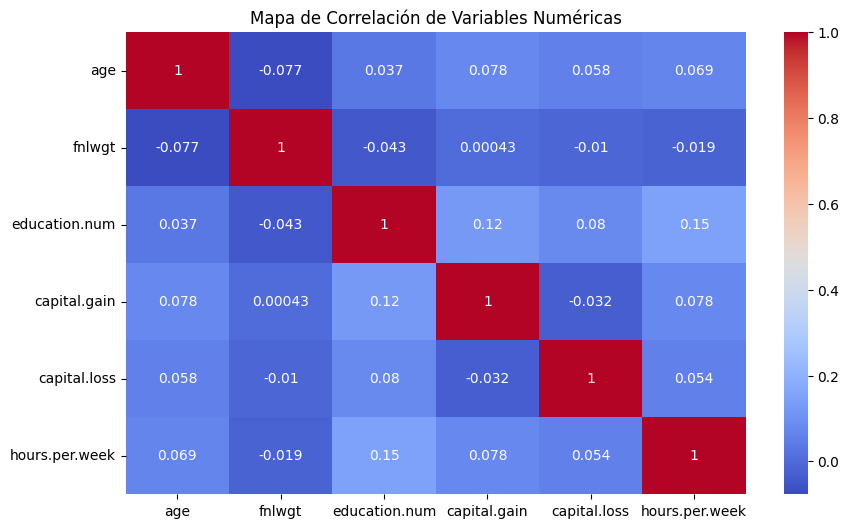

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Mapa de Correlación de Variables Numéricas")
plt.show()

In [9]:
# Preprocesamiento (Limpieza, One-Hot Encoding y Split)
#Tratamiento de nulos
df.dropna(inplace=True)

In [10]:
# 6. Variables predictoras (X) y objetivo (y)
X = df.drop('income', axis=1) # Todas menos income
y = df['income'] # Nuestra variable a predecir

In [11]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [12]:
print(f"Columnas originales: {X.shape[1]}")
print(f"Columnas después de One-Hot Encoding: {X_encoded.shape[1]}")

Columnas originales: 14
Columnas después de One-Hot Encoding: 96


In [13]:
#Train/Test Split (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [14]:
print(f"\nRegistros para entrenamiento: {X_train.shape[0]}")
print(f"Registros para prueba: {X_test.shape[0]}")


Registros para entrenamiento: 24129
Registros para prueba: 6033


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
#Entrenamiento, Predicción y Evaluación
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
y_pred = modelo.predict(X_test_scaled)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo: {accuracy * 100:.2f}%\n")

Accuracy del modelo: 80.18%



In [19]:
importancias = modelo.feature_importances_
nombres_features = X_encoded.columns

In [20]:
# Creamos un DataFrame para ver qué variables importan más
df_importancias = pd.DataFrame({'Variable': nombres_features, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

In [21]:
print("=== TOP 5 VARIABLES MÁS IMPORTANTES ===")
print(df_importancias.head())

=== TOP 5 VARIABLES MÁS IMPORTANTES ===
                             Variable  Importancia
28  marital.status_Married-civ-spouse     0.202047
1                              fnlwgt     0.185471
2                       education.num     0.119017
0                                 age     0.110697
3                        capital.gain     0.104066


In [22]:
print("\n=== TOP 5 VARIABLES MENOS IMPORTANTES ===")
print(df_importancias.tail())


=== TOP 5 VARIABLES MENOS IMPORTANTES ===
                                     Variable  Importancia
83                        native.country_Peru          0.0
82  native.country_Outlying-US(Guam-USVI-etc)          0.0
91                    native.country_Thailand          0.0
88                    native.country_Scotland          0.0
90                      native.country_Taiwan          0.0
